<a href="https://colab.research.google.com/github/ginasoft/vision-computacional/blob/main/Clase10_Actividad_YOLO_Cuellas_Natalia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics roboflow -q

import ultralytics
ultralytics.checks()  # verifica version y GPU disponible

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 70.6ms
Speed: 5.3ms preprocess, 70.6ms inference, 41.6ms postprocess per image at shape (1, 3, 640, 480)


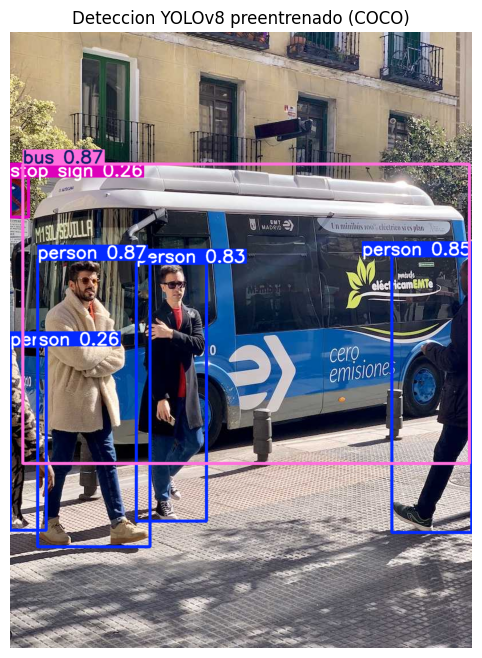

In [2]:
from ultralytics import YOLO

# Cargamos el modelo preentrenado (n = nano, rapido y liviano)
model = YOLO('yolov8n.pt')

# Imagen de ejemplo (calle con personas y autos)
results = model('https://ultralytics.com/images/bus.jpg')

# Mostramos el resultado con las bounding boxes dibujadas
from PIL import Image
import matplotlib.pyplot as plt

res_plotted = results[0].plot()  # dibuja cajas + etiquetas + confianza
plt.figure(figsize=(10, 8))
plt.imshow(res_plotted[..., ::-1])  # BGR -> RGB
plt.axis('off')
plt.title('Deteccion YOLOv8 preentrenado (COCO)')
plt.show()

In [3]:
# Vemos el detalle: clase, confianza y coordenadas de cada bounding box
for box in results[0].boxes:
    clase = model.names[int(box.cls)]
    confianza = float(box.conf)
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    print(f'{clase:10s} | confianza={confianza:.2f} | box=({x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f})')

bus        | confianza=0.87 | box=(23,231,805,757)
person     | confianza=0.87 | box=(49,399,245,903)
person     | confianza=0.85 | box=(669,392,810,877)
person     | confianza=0.83 | box=(222,406,345,858)
person     | confianza=0.26 | box=(0,551,63,873)
stop sign  | confianza=0.26 | box=(0,254,33,325)


In [4]:
# Dataset de prueba oficial de Ultralytics: COCO128 (128 imagenes, 80 clases)
# Util para demostrar entrenamiento real sin descargar GB de datos
from ultralytics.utils.downloads import download

download('https://ultralytics.com/assets/coco128.zip', dir='datasets')
!ls datasets/coco128

Unzipping datasets/coco128.zip to /content/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 3.4Kfiles/s 0.1s
images	labels	LICENSE  README.txt


In [5]:
from ultralytics import YOLO

# Partimos del modelo preentrenado (transfer learning) y lo afinamos al dataset
model = YOLO('yolov8n.pt')

# Si usaste Roboflow:  data = dataset.location + '/data.yaml'
# Si usaste COCO128:   data = 'coco128.yaml'
results = model.train(
    data='coco128.yaml',
    epochs=15,
    imgsz=640,        # la imagen se redimensiona a cuadrado 640x640
    batch=16,
    name='yolo_actividad'
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_actividad, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

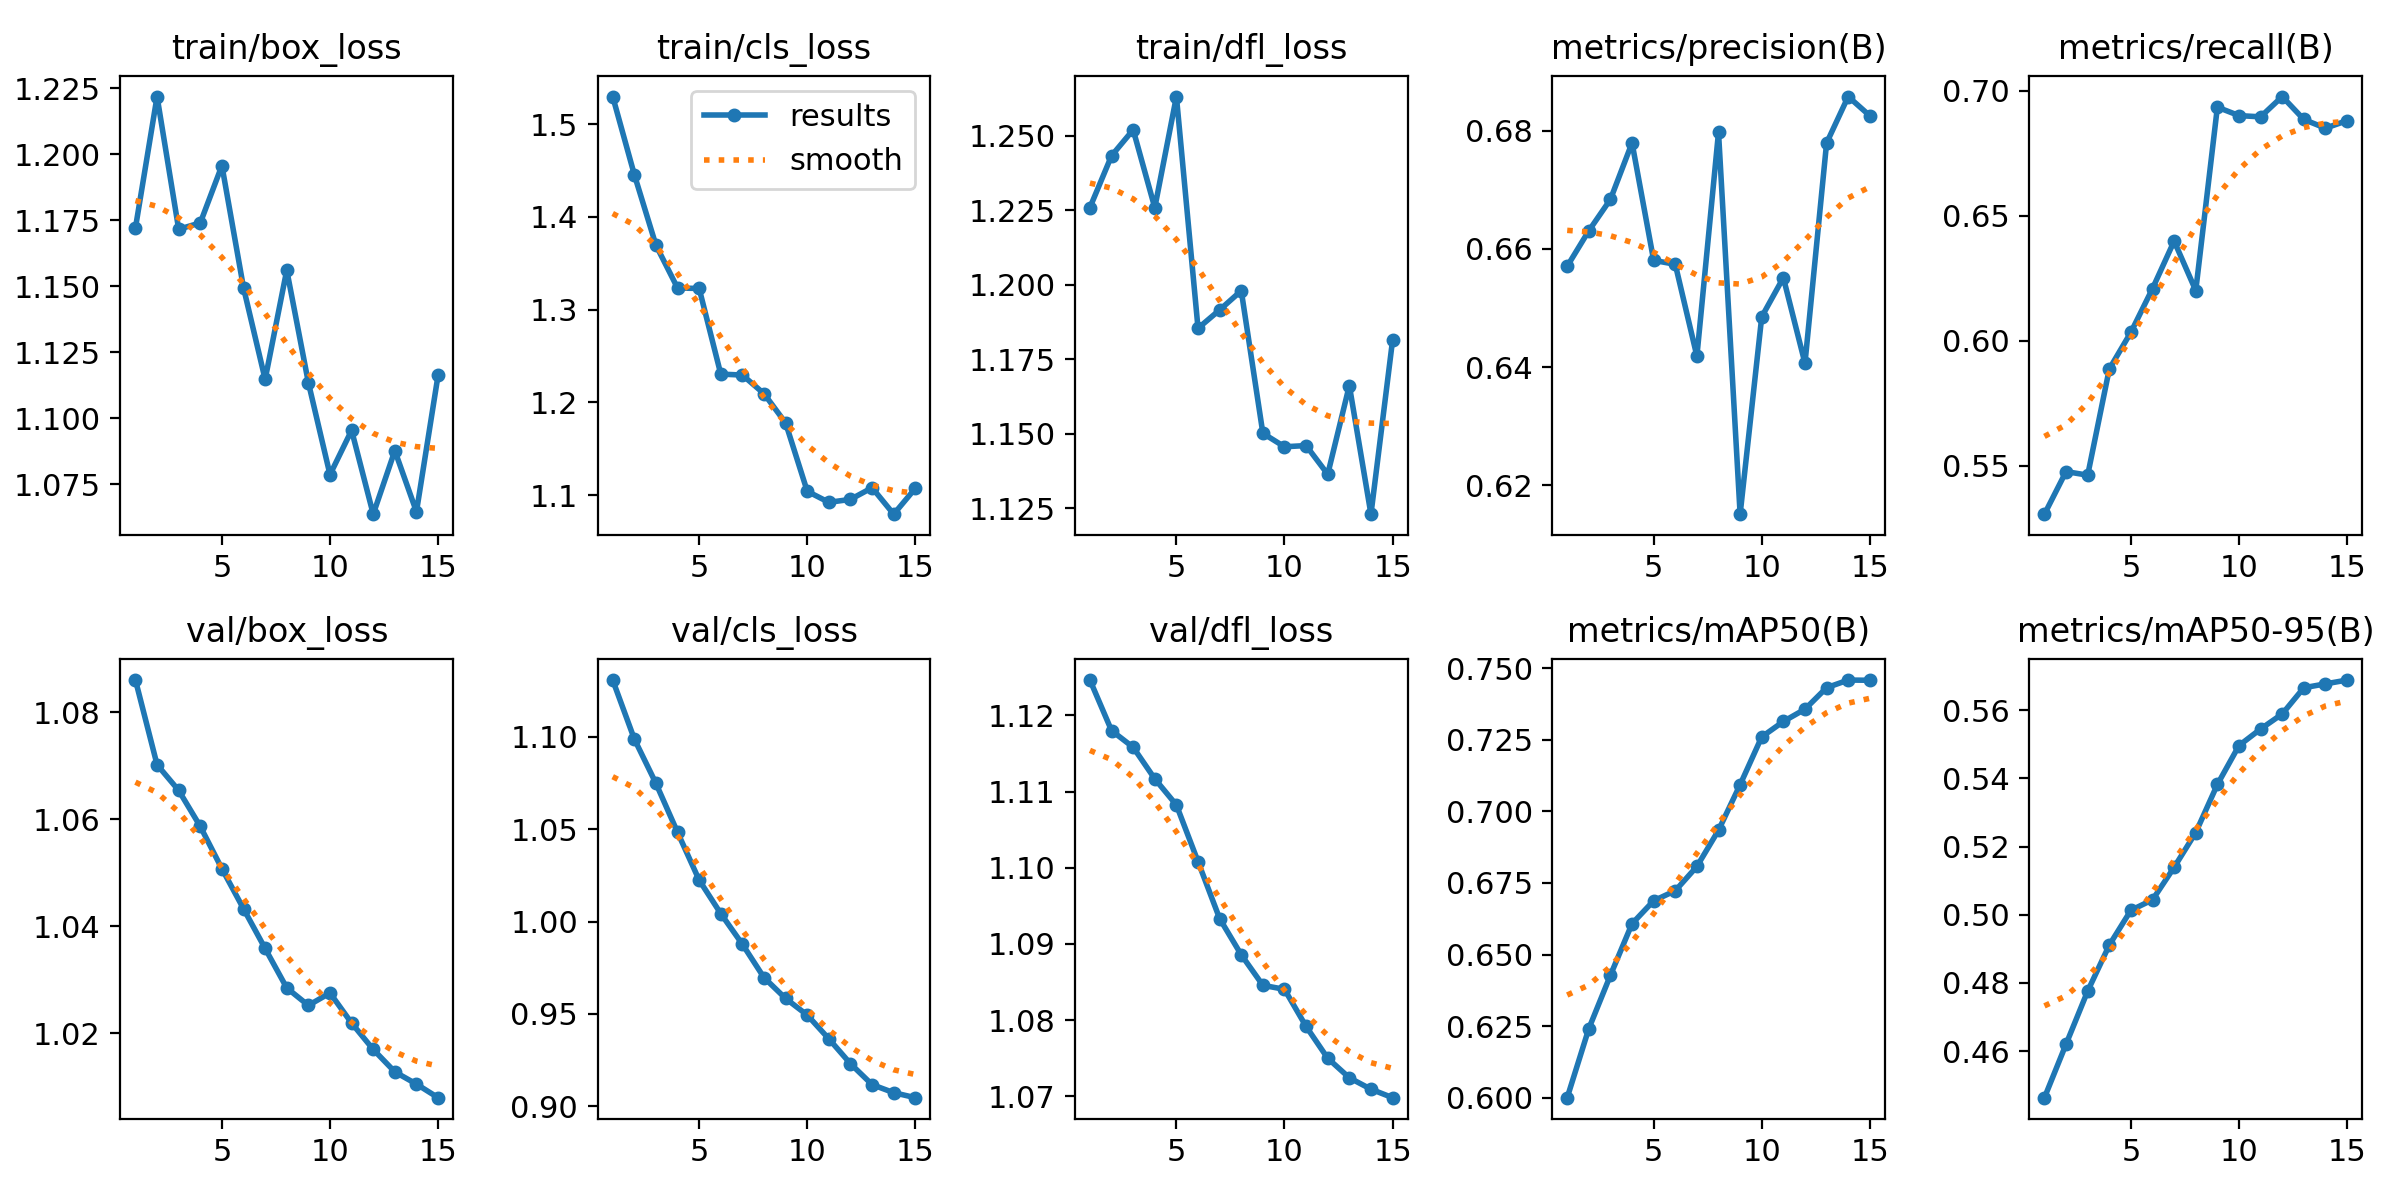

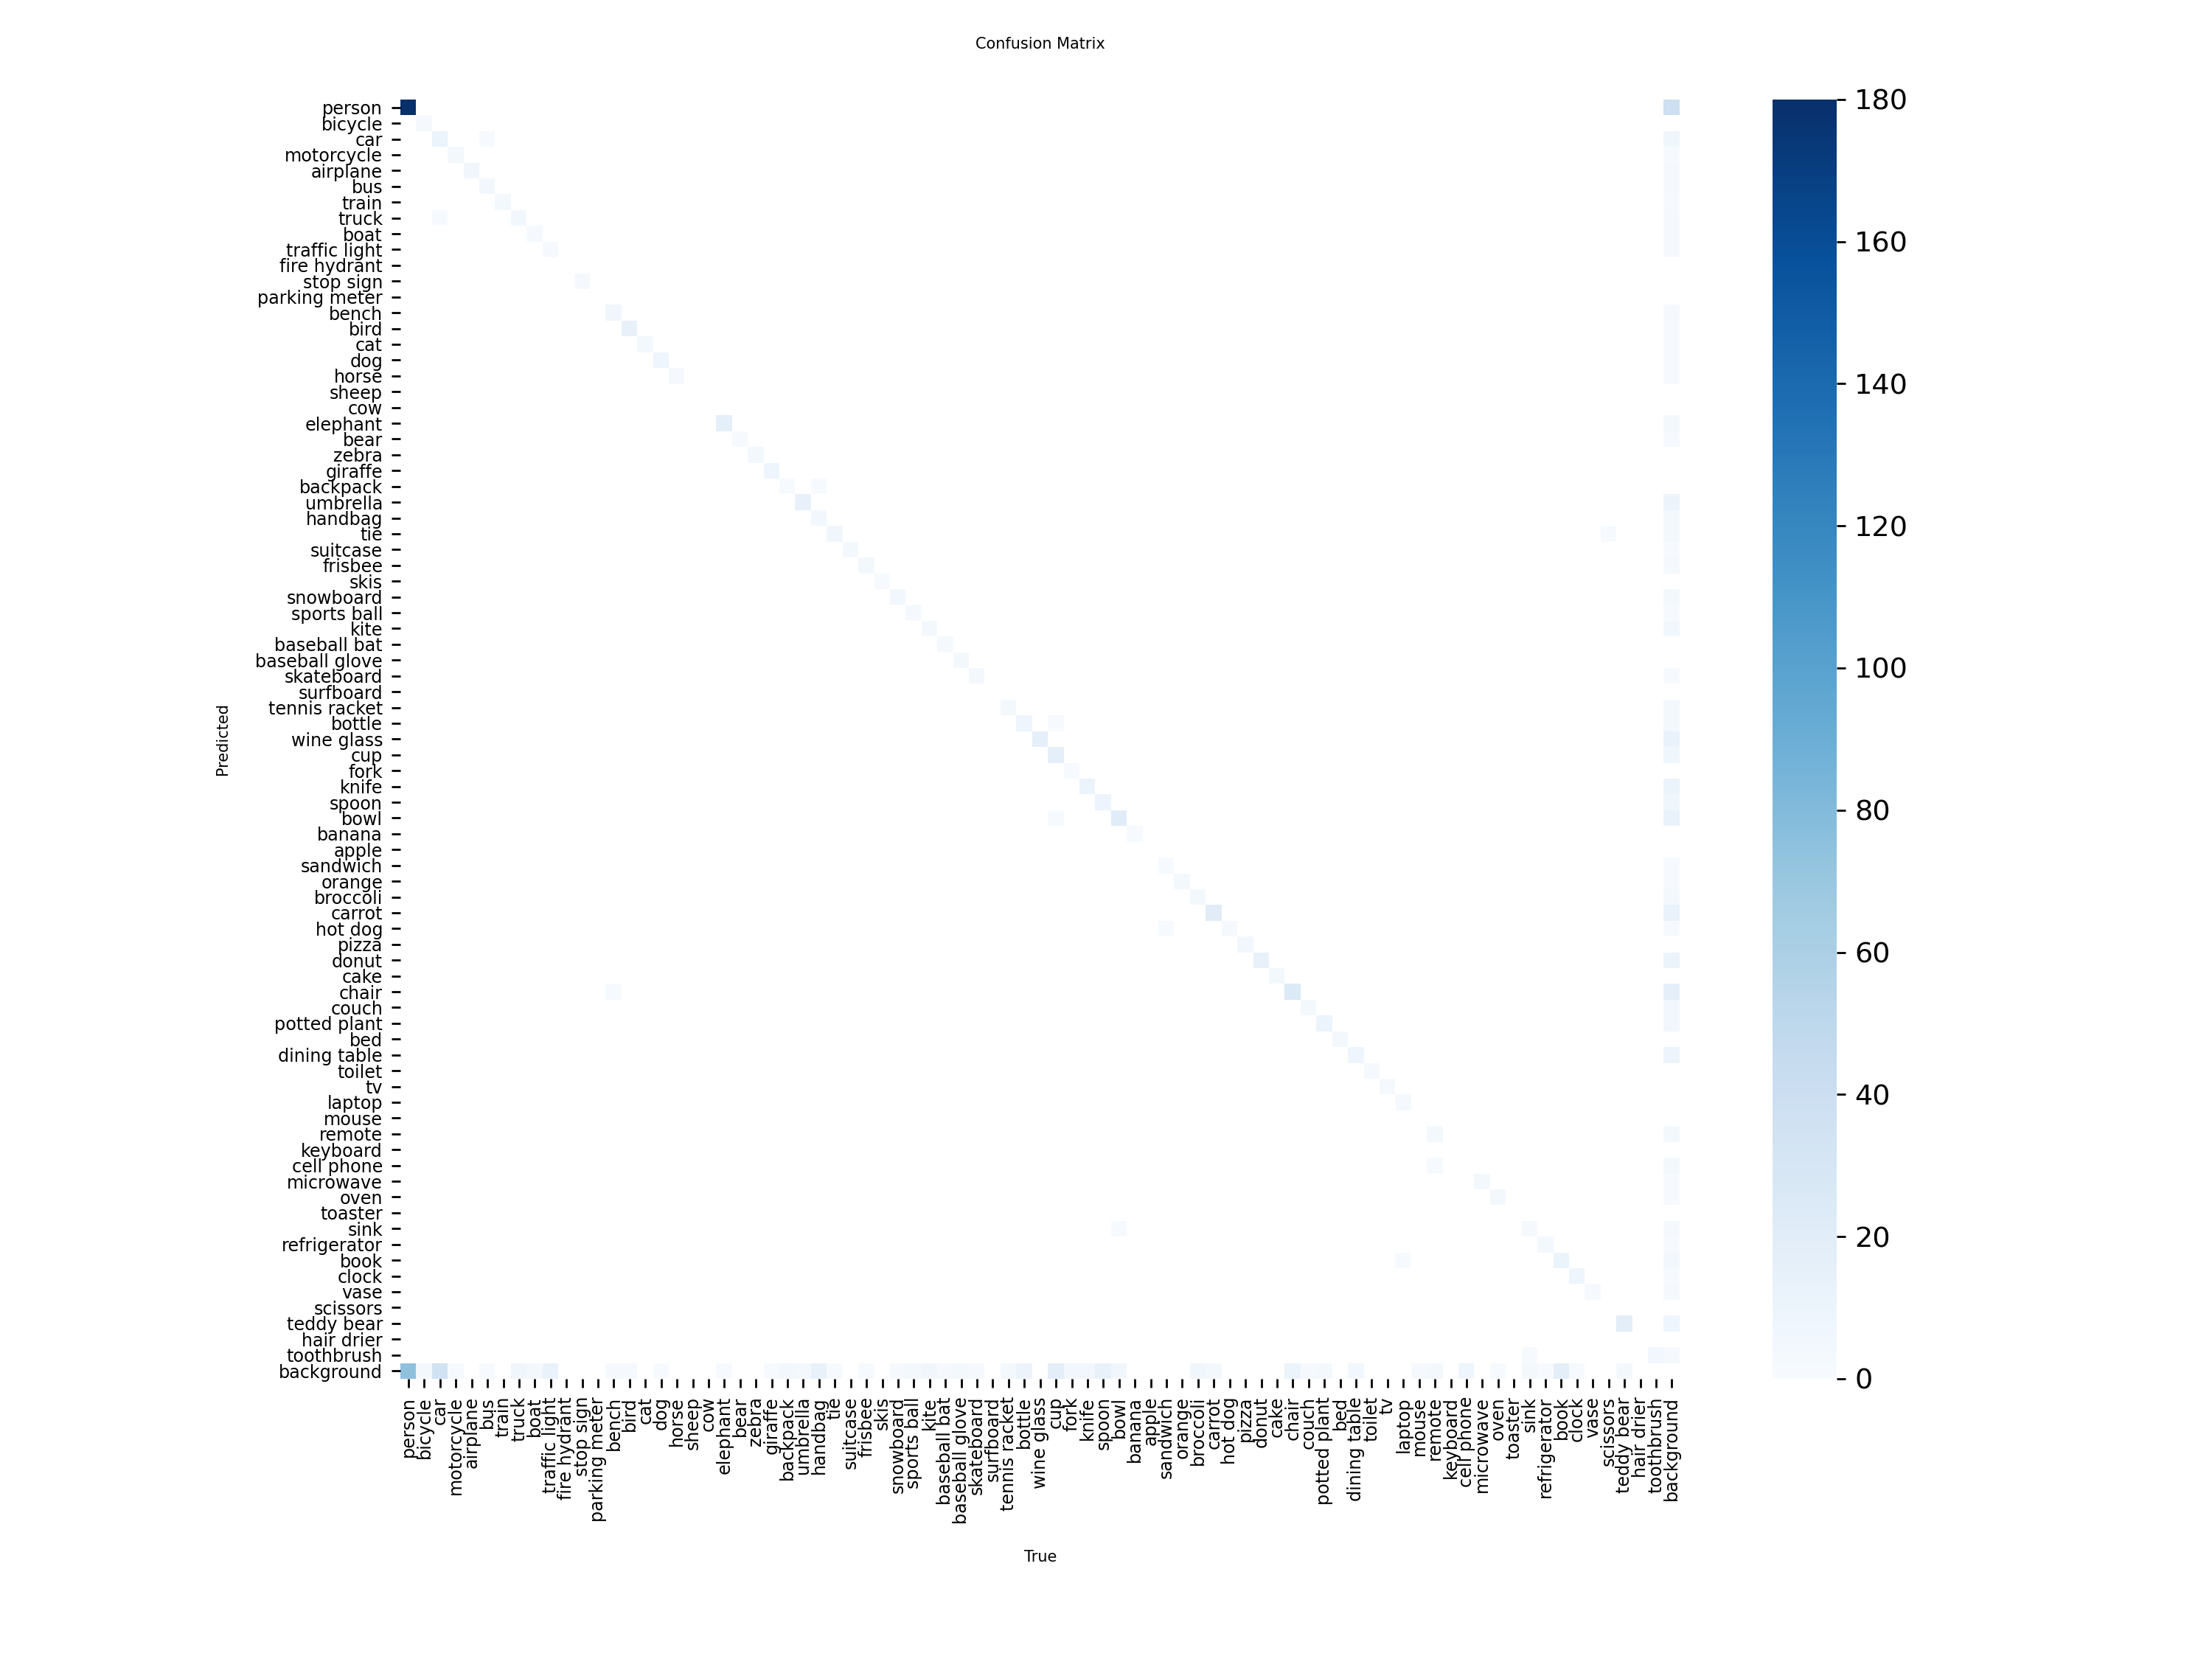

In [6]:
from IPython.display import Image as IPImage
import glob, os

run_dir = 'runs/detect/yolo_actividad'

# Curvas de entrenamiento (loss, precision, recall, mAP)
if os.path.exists(f'{run_dir}/results.png'):
    display(IPImage(f'{run_dir}/results.png', width=900))

# Matriz de confusion
if os.path.exists(f'{run_dir}/confusion_matrix.png'):
    display(IPImage(f'{run_dir}/confusion_matrix.png', width=700))


0: 640x640 4 persons, 2 benchs, 11.9ms
1: 640x640 1 pizza, 1 refrigerator, 11.9ms
2: 640x640 3 persons, 4 tennis rackets, 22 chairs, 11.9ms
3: 640x640 1 clock, 1 vase, 11.9ms
Speed: 1.6ms preprocess, 11.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


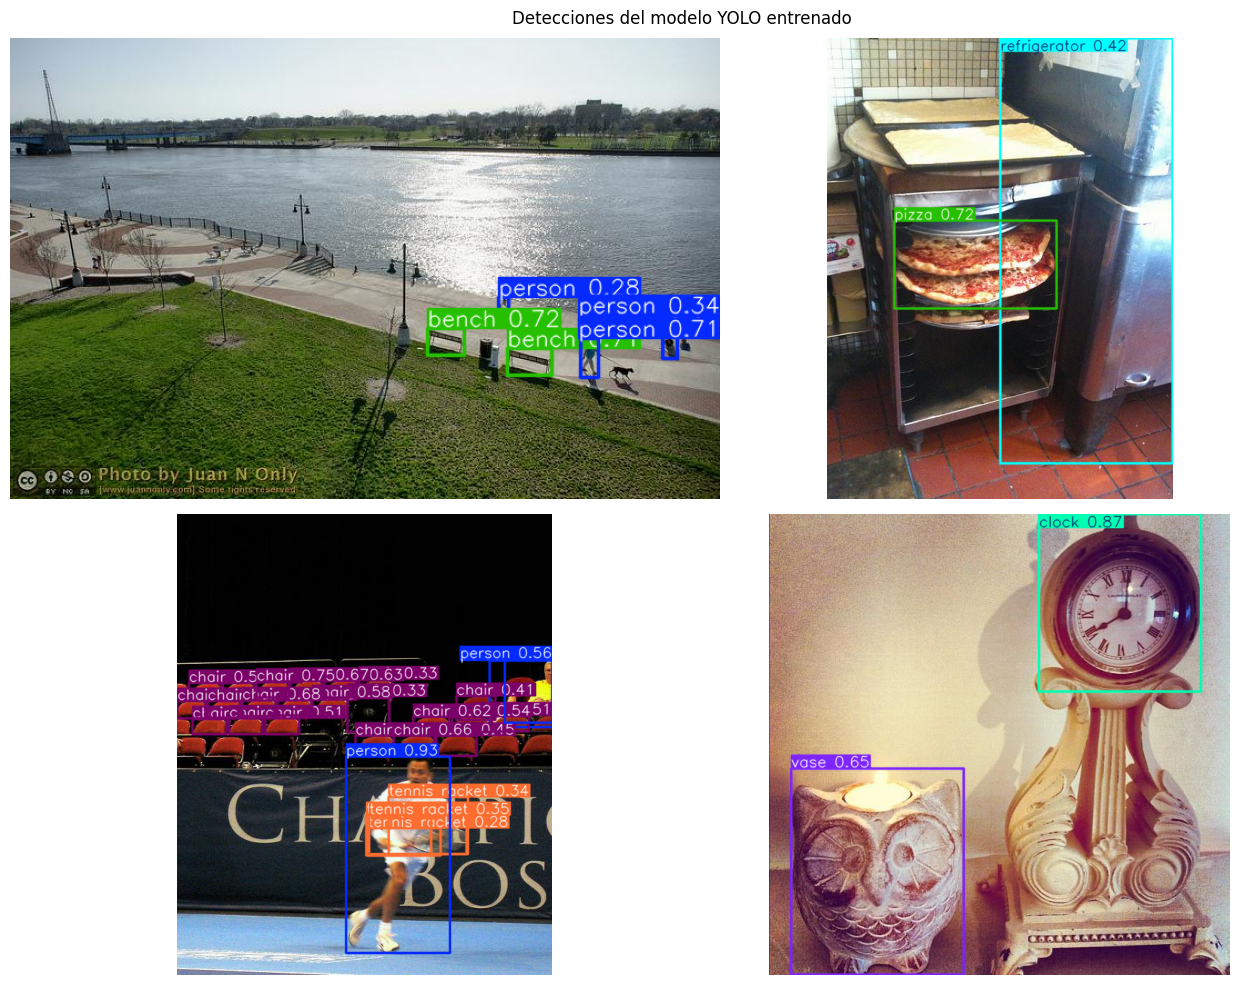

In [7]:
import matplotlib.pyplot as plt
import glob

# Cargamos los pesos entrenados
best = YOLO(f'{run_dir}/weights/best.pt')

# Predecimos sobre algunas imagenes del set de validacion
imgs = glob.glob('datasets/coco128/images/train2017/*.jpg')[:4]
preds = best(imgs)

# Mostramos 4 resultados en grilla
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, pred in zip(axes.ravel(), preds):
    ax.imshow(pred.plot()[..., ::-1])  # BGR -> RGB
    ax.axis('off')
plt.suptitle('Detecciones del modelo YOLO entrenado')
plt.tight_layout()
plt.show()